<a href="https://colab.research.google.com/github/mayconalbuquerque1/Pos_Tech_FIAP/blob/Machine_Learning/Machine_Learning_and_Time_Series.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Principais bibliotecas do Machine Learning

## Pandas

### Bibliotecas

In [ ]:
! pip install pandas

In [ ]:
import pandas as pd

### Extração dos dados

In [ ]:
df_excel = pd.read_excel("Chess.xlsx", sheet_name="Chess")

In [ ]:
df_csv = pd.read_csv("Tomato.csv", sep=",")

### Análise dos Dados

In [ ]:
df_excel.shape

(20058, 14)

In [ ]:
df_excel.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20058 entries, 0 to 20057
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   rated           20058 non-null  bool   
 1   created_at      20058 non-null  float64
 2   last_move_at    20058 non-null  float64
 3   turns           20058 non-null  int64  
 4   victory_status  20058 non-null  object 
 5   winner          20058 non-null  object 
 6   increment_code  20058 non-null  object 
 7   white_id        20058 non-null  object 
 8   white_rating    20058 non-null  int64  
 9   black_id        20058 non-null  object 
 10  black_rating    20058 non-null  int64  
 11  opening_eco     20058 non-null  object 
 12  opening_name    20058 non-null  object 
 13  opening_ply     20058 non-null  int64  
dtypes: bool(1), float64(2), int64(4), object(7)
memory usage: 2.0+ MB


In [ ]:
df_excel.head()

,rated,created_at,last_move_at,turns,victory_status,winner,increment_code,white_id,white_rating,black_id,black_rating,opening_eco,opening_name,opening_ply
0,False,1.504210e+17,1.504210e+17,13,outoftime,white,15+2,bourgris,1500,a-00,1191,D10,Slav Defense: Exchange Variation,5
1,True,1.504130e+17,1.504130e+17,16,resign,black,5+10,a-00,1322,skinnerua,1261,B00,Nimzowitsch Defense: Kennedy Variation,4
2,True,1.504130e+17,1.504130e+17,61,mate,white,5+10,ischia,1496,a-00,1500,C20,King's Pawn Game: Leonardis Variation,3
3,True,1.504110e+17,1.504110e+17,61,mate,white,20+0,daniamurashov,1439,adivanov2009,1454,D02,Queen's Pawn Game: Zukertort Variation,3
4,True,1.504030e+17,1.504030e+17,95,mate,white,30+3,nik221107,1523,adivanov2009,1469,C41,Philidor Defense,5


In [ ]:
set(df_excel['victory_status'])

{'draw', 'mate', 'outoftime', 'resign'}

In [ ]:
df_csv.head()

,Date,Unit,Minimum,Maximum,Average,Market
0,2013-06-16,Kg,26,32,29.0,Tomato
1,2013-06-17,Kg,20,25,22.5,Tomato
2,2013-06-18,Kg,22,26,24.0,Tomato
3,2013-06-19,Kg,24,28,26.0,Tomato
4,2013-06-20,Kg,22,26,24.0,Tomato


### Adicionar uma nova coluna

In [ ]:
def categorizar_tomate_media(media):
  if media >= 40 and media <= 70:
    return "Tomate Médio"
  elif media < 40:
    return "Tomate Pequeno"
  else:
    return "Tomate Grande"

In [ ]:
df_csv['categoria_tomate'] = df_csv['Average'].apply(categorizar_tomate_media)

In [ ]:
df_csv.head()

,Date,Unit,Minimum,Maximum,Average,Market,categoria_tomate
0,2013-06-16,Kg,26,32,29.0,Tomato,Tomate Pequeno
1,2013-06-17,Kg,20,25,22.5,Tomato,Tomate Pequeno
2,2013-06-18,Kg,22,26,24.0,Tomato,Tomate Pequeno
3,2013-06-19,Kg,24,28,26.0,Tomato,Tomate Pequeno
4,2013-06-20,Kg,22,26,24.0,Tomato,Tomate Pequeno


In [ ]:
df_csv.groupby(['categoria_tomate']).describe()

Minimum                                                      \
                   count       mean       std   min   25%   50%   75%    max   
categoria_tomate                                                               
Tomate Grande      149.0  75.744966  7.324666  65.0  70.0  75.0  80.0  115.0   
Tomate Médio       954.0  47.818658  8.203065  30.0  40.0  45.0  55.0   65.0   
Tomate Pequeno    1638.0  23.978022  7.175572   8.0  18.0  25.0  30.0   38.0   

                 Maximum             ...              Average             \
                   count       mean  ...   75%    max   count       mean   
categoria_tomate                     ...                                   
Tomate Grande      149.0  82.583893  ...  85.0  120.0   149.0  79.164430   
Tomate Médio       954.0  55.009434  ...  60.0   75.0   954.0  51.414046   
Tomate Pequeno    1638.0  29.528694  ...  35.0   44.0  1638.0  26.753358   

                                                           
                       std   min   25%   50%   75%    max  
categoria_tomate                                           
Tomate Grande     7.367396  70.5  75.0  77.5  82.5  117.5  
Tomate Médio      8.272792  40.0  45.0  50.0  57.5   70.0  
Tomate Pequeno    7.191735  10.0  21.5  27.5  32.5   39.5  

[3 rows x 24 columns]

In [ ]:
filtro = df_csv['Average'] < 40
df_csv.loc[filtro]

,Date,Unit,Minimum,Maximum,Average,Market,categoria_tomate
0,2013-06-16,Kg,26,32,29.0,Tomato,Tomate Pequeno
1,2013-06-17,Kg,20,25,22.5,Tomato,Tomate Pequeno
2,2013-06-18,Kg,22,26,24.0,Tomato,Tomate Pequeno
3,2013-06-19,Kg,24,28,26.0,Tomato,Tomate Pequeno
4,2013-06-20,Kg,22,26,24.0,Tomato,Tomate Pequeno
...,...,...,...,...,...,...,...
2736,2021-05-09,Kg,10,15,12.5,Tomato,Tomate Pequeno
2737,2021-05-10,Kg,10,15,12.5,Tomato,Tomate Pequeno
2738,2021-05-11,Kg,10,15,12.5,Tomato,Tomate Pequeno
2739,2021-05-12,Kg,30,35,32.5,Tomato,Tomate Pequeno


## Numpy

### Biblioteca

In [ ]:
import numpy as np

### Criação e Edição de Lista

In [ ]:
arr_list = np.array([1, 2, 3, 4, 5, 6, 7, 8])

In [ ]:
print(arr_list)

[1 2 3 4 5 6 7 8]


In [ ]:
arr_zeros = np.zeros((4, 6))
print(arr_zeros)

[[0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]]


In [ ]:
arr_ones = np.ones((4, 6))
print(arr_ones)

[[1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1.]]


In [ ]:
arr_random = np.random.rand(3,4)
print(arr_random)

[[0.53260272 0.6079132  0.39254009 0.35363359]
 [0.07736037 0.09574372 0.99301055 0.28223327]
 [0.95853222 0.26517039 0.97629984 0.85962765]]


In [ ]:
print(arr_random.shape)

(3, 4)


In [ ]:
arr_random_reshape = arr_random.reshape(4,3)
print(arr_random_reshape)

[[0.53260272 0.6079132  0.39254009]
 [0.35363359 0.07736037 0.09574372]
 [0.99301055 0.28223327 0.95853222]
 [0.26517039 0.97629984 0.85962765]]


In [ ]:
arr1 = np.array([[1, 2], [3, 4]])
arr2 = np.array([[5, 6], [7, 8]])
arr3 = np.array([[9, 10], [11, 12]])

In [ ]:
arr4 = np.concatenate((arr1, arr2, arr3), axis=0)
print(arr4)

[[ 1  2]
 [ 3  4]
 [ 5  6]
 [ 7  8]
 [ 9 10]
 [11 12]]


In [ ]:
arr4_split = np.split(arr4, 2)
print(arr4_split)

[array([[1, 2],
       [3, 4],
       [5, 6]]), array([[ 7,  8],
       [ 9, 10],
       [11, 12]])]


In [ ]:
arr4_transpose = np.transpose(arr4)

In [ ]:
print(arr4_transpose)

[[ 1  3  5  7  9 11]
 [ 2  4  6  8 10 12]]


In [ ]:
arr4_revertido = arr4_transpose.T
print(arr4_revertido)

[[ 1  2]
 [ 3  4]
 [ 5  6]
 [ 7  8]
 [ 9 10]
 [11 12]]


### Operações Matemáticas

In [ ]:
arr_a = np.array([1, 7, 27])
arr_b = np.array([1, 5, 1])

In [ ]:
arr_a_b = np.add(arr_a, arr_b)
print(arr_a_b)

[ 2 12 28]


In [ ]:
arr_sub_a_b = np.subtract(arr_a, arr_b)
print(arr_sub_a_b)

[ 0  2 26]


##Matplotlib

###Biblioteca

In [ ]:
import matplotlib.pyplot as plt

###Validando Types

In [ ]:
df_csv.head()

,Date,Unit,Minimum,Maximum,Average,Market,categoria_tomate
0,2013-06-16,Kg,26,32,29.0,Tomato,Tomate Pequeno
1,2013-06-17,Kg,20,25,22.5,Tomato,Tomate Pequeno
2,2013-06-18,Kg,22,26,24.0,Tomato,Tomate Pequeno
3,2013-06-19,Kg,24,28,26.0,Tomato,Tomate Pequeno
4,2013-06-20,Kg,22,26,24.0,Tomato,Tomate Pequeno


In [ ]:
df_csv["Date"] = pd.to_datetime(df_csv["Date"])

In [ ]:
df_csv.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2741 entries, 0 to 2740
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Date              2741 non-null   datetime64[ns]
 1   Unit              2741 non-null   object        
 2   Minimum           2741 non-null   int64         
 3   Maximum           2741 non-null   int64         
 4   Average           2741 non-null   float64       
 5   Market            2741 non-null   object        
 6   categoria_tomate  2741 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(3)
memory usage: 150.0+ KB


###Plots

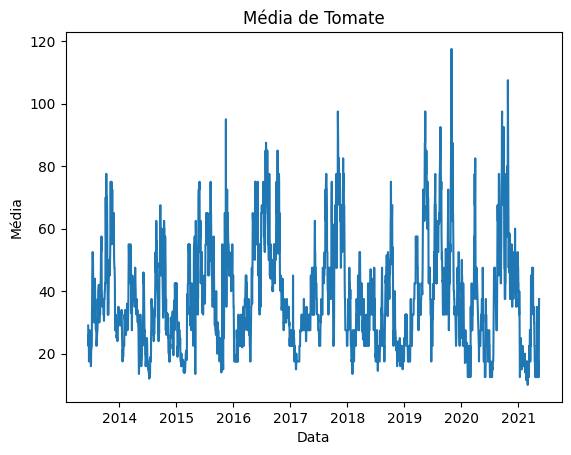

In [ ]:
plt.plot(df_csv["Date"], df_csv["Average"])
plt.xlabel("Data")
plt.ylabel("Média")
plt.title("Média de Tomate")
plt.show()

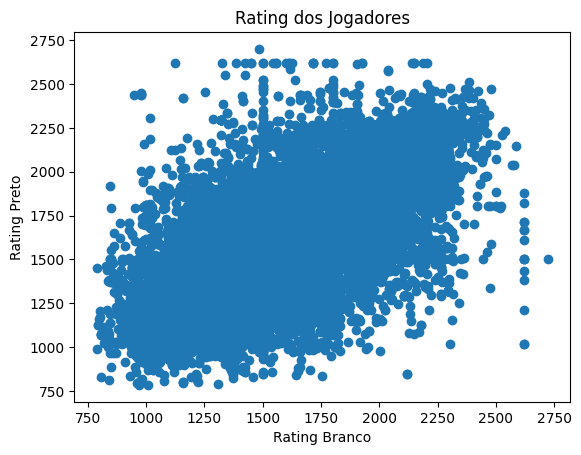

In [ ]:
plt.scatter(df_excel["black_rating"], df_excel["white_rating"])
plt.xlabel("Rating Branco")
plt.ylabel("Rating Preto")
plt.title("Rating dos Jogadores")
plt.show()

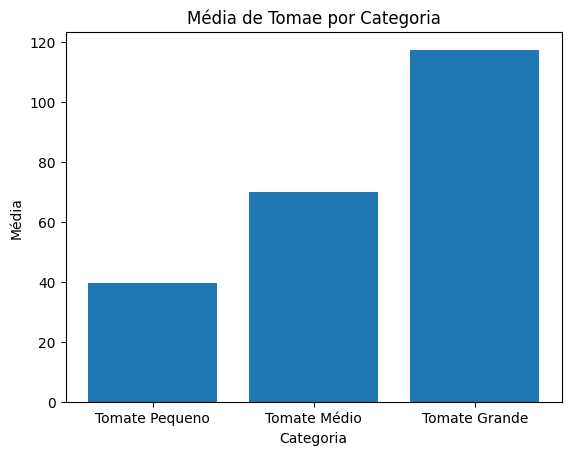

In [ ]:
plt.bar(df_csv["categoria_tomate"], df_csv["Average"])
plt.xlabel("Categoria")
plt.ylabel("Média")
plt.title("Média de Tomae por Categoria")
plt.show()

In [ ]:
chess = df_excel

chess.head(3)

,rated,created_at,last_move_at,turns,victory_status,winner,increment_code,white_id,white_rating,black_id,black_rating,opening_eco,opening_name,opening_ply
0,False,1.504210e+17,1.504210e+17,13,outoftime,white,15+2,bourgris,1500,a-00,1191,D10,Slav Defense: Exchange Variation,5
1,True,1.504130e+17,1.504130e+17,16,resign,black,5+10,a-00,1322,skinnerua,1261,B00,Nimzowitsch Defense: Kennedy Variation,4
2,True,1.504130e+17,1.504130e+17,61,mate,white,5+10,ischia,1496,a-00,1500,C20,King's Pawn Game: Leonardis Variation,3


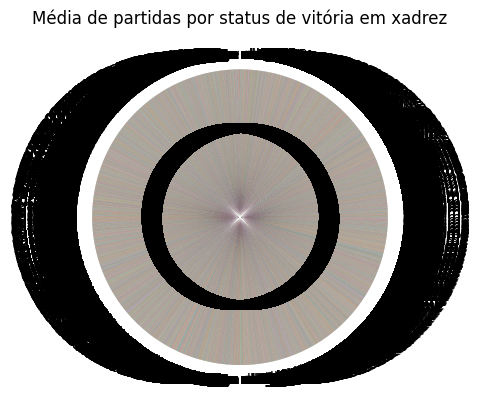

In [ ]:
# Gráfico de pizza
mean_value = chess['turns'].mean()
plt.pie(chess['turns'], labels=chess['victory_status'], autopct='%1.0f%%')
plt.title('Média de partidas por status de vitória em xadrez')
plt.show()

##Scikit-Learn

###Conhecendo o Scikit-Learn

A biblioteca do scikit-Learn é uma poderosa biblioteca de ferramentas para trabalhar com os principais algoritmos de machine learning e deep learning, sem contar as inúmeras opções de ferramentas de transformações em dados.

In [ ]:
import pandas as pd

In [ ]:
! pip install scikit-learn

In [ ]:
df_diabetes = pd.read_csv("diabetes.csv", sep=",")

In [ ]:
df_diabetes.head(1)

,Number of times pregnant,Plasma glucose concentration a 2 hours in an oral glucose tolerance test,Diastolic blood pressure (mm Hg),Triceps skin fold thickness (mm),2-Hour serum insulin (mu U/ml),Body mass index (weight in kg/(height in m)^2),Diabetes pedigree function,Age (years),Class variable
0,6,148,72,35,0,33.6,0.627,50,1


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x = df_diabetes.drop(['Class variable'], axis = 1)
y = df_diabetes['Class variable']

In [ ]:
x

,Number of times pregnant,Plasma glucose concentration a 2 hours in an oral glucose tolerance test,Diastolic blood pressure (mm Hg),Triceps skin fold thickness (mm),2-Hour serum insulin (mu U/ml),Body mass index (weight in kg/(height in m)^2),Diabetes pedigree function,Age (years)
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33
...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63
764,2,122,70,27,0,36.8,0.340,27
765,5,121,72,23,112,26.2,0.245,30
766,1,126,60,0,0,30.1,0.349,47


In [ ]:
y

,Class variable
0,1
1,0
2,1
3,0
4,1
...,...
763,0
764,0
765,0
766,1


In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3)

len(x_train)

537

In [ ]:
df_diabetes.shape

(768, 9)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(x_train, y_train)

KNeighborsClassifier(n_neighbors=3)

In [ ]:
accuracy = knn.score(x_test, y_test)
print(accuracy)

0.683982683982684
